In [10]:
using Distributions
using Plots
using Random
using StatsPlots

### Coin Flipping withouth `Turing`

In [22]:
ptrue = 0.5
N = 100
ns = 0:N

0:100

In [23]:
# Random.seed!(9086)
data = rand(Bernoulli(ptrue), N)
data[1:5]

5-element Array{Int64,1}:
 1
 1
 1
 1
 1

In [24]:
betaprior = Beta(1, 1)

Beta{Float64}(α=1.0, β=1.0)

┌ Info: Saved animation to 
│   fn = /Users/dsp/Learning/julia/turing/tutorial/tmp.gif
└ @ Plots /Users/dsp/.julia/packages/Plots/qZHsp/src/animation.jl:98


Plots.AnimatedGif("/Users/dsp/Learning/julia/turing/tutorial/tmp.gif")
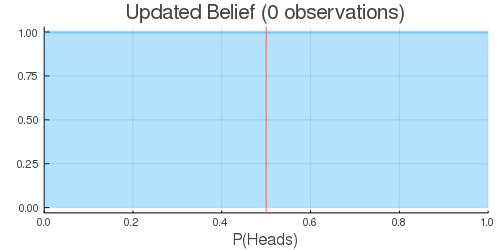

In [25]:
anim = @gif for (i, N) in enumerate(ns) # julia enumeration is 1-based
    nheads = sum(data[1:i - 1])
    ntails = N - nheads
    posterior = Beta(betaprior.α + nheads, betaprior.β + ntails)
    plot(posterior,
         size=(500, 250),
         title="Updated Belief ($N observations)",
         xlabel="P(Heads)",
         legend=nothing,
         xlim=(0, 1),
         fill=0,
         α=0.3,
         w=3)
    vline!([ptrue])
end

### Coin Flipping _with_ `Turing`